### 基于装饰器的 Node-Style Hook

除了继承 `AgentMiddleware` 类来写中间件，LangChain 还提供了一组**装饰器**，可以把普通函数直接变成中间件。这些钩子挂在 Agent 执行图的特定**节点**上（agent 开始/结束、model 节点、tools 节点），所以称为 **node-style hook**。

每个装饰器都会返回一个 `AgentMiddleware`，直接放进 `create_agent(middleware=[...])` 即可：

```python
@before_model
def my_hook(state: AgentState, runtime: Runtime) -> None:
    print('即将调用模型')

agent = create_agent(model, middleware=[my_hook])
```

| 装饰器 | 触发时机 | 函数签名 |
| --- | --- | --- |
| `@before_agent` | 整个 Agent 开始前（一次） | `(state, runtime)` |
| `@after_agent` | 整个 Agent 结束后（一次） | `(state, runtime)` |
| `@before_model` | 每次调用模型**前** | `(state, runtime)` |
| `@after_model` | 每次调用模型**后** | `(state, runtime)` |
| `@wrap_model_call` | **包裹**模型调用（可重试/改写响应） | `(request, handler)` |
| `@wrap_tool_call` | **包裹**工具调用（可重试/改参/缓存） | `(request, handler)` |
| `@dynamic_prompt` | 动态生成系统提示 | `(request) -> str` |

公共参数（部分装饰器支持）：`state_schema`（自定义状态）、`tools`（额外注册工具）、`can_jump_to`（允许的条件跳转）、`name`（中间件名）。

> 这些函数可以是同步 `def`，也可以是异步 `async def`；`before_*` / `after_*` 返回 `dict`（状态更新）、`Command`（流程控制）或 `None`。

In [1]:
import os

from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain.agents.middleware import (
    after_agent,
    after_model,
    before_agent,
    before_model,
)
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool

load_dotenv(override=True)

model = init_chat_model(
    api_base=os.getenv("DEEPSEEK_API_BASE"),
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    model="deepseek-flash",
    model_provider="deepseek",
    model_kwargs={"reasoning_effort": "none"},
)


@tool
def get_time(city: str) -> str:
    """查询城市当前时间。

    :param city: 城市名
    """
    return f"{city} 现在是 12:00"


/Users/lijixu/PycharmProjects/langchain_demo/.venv/lib/python3.14/site-packages/langchain_core/utils/pydantic.py:42: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1
/Users/lijixu/PycharmProjects/langchain_demo/.venv/lib/python3.14/site-packages/langchain/chat_models/base.py:516: UserWarning: Parameters {'reasoning_effort'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  return _init_chat_model_helper(


#### 生命周期钩子：before_agent / after_agent / before_model / after_model

In [2]:
# 用列表记录各钩子的执行顺序
log = []


@before_agent
def log_before_agent(state, runtime):
    """整个 Agent 开始前执行一次。"""
    log.append("before_agent")


@before_model
def log_before_model(state, runtime):
    """每次调用模型前执行（包括工具调用后的再一次调用）。"""
    log.append("before_model")


@after_model
def log_after_model(state, runtime):
    """每次调用模型后执行。"""
    log.append("after_model")


@after_agent
def log_after_agent(state, runtime):
    """整个 Agent 结束后执行一次。"""
    log.append("after_agent")


agent = create_agent(
    model=model,
    tools=[get_time],
    middleware=[log_before_agent, log_before_model, log_after_model, log_after_agent],
)

result = agent.invoke({"messages": [{"role": "user", "content": "上海几点了？"}]})

# 因为有工具调用，模型被调用了两次，所以 before_model / after_model 各出现两次
print("执行顺序：", log)
print("回复：", result["messages"][-1].content)


执行顺序： ['before_agent', 'before_model', 'after_model', 'before_model', 'after_model', 'after_agent']
回复： 上海现在是 12:00。


执行顺序为：`before_agent → (before_model → after_model) × N → after_agent`，其中 `N` 是模型被调用的次数（有工具调用时大于 1）。

#### dynamic_prompt：动态生成系统提示

In [3]:
# 装饰器函数接收 ModelRequest，返回字符串或 SystemMessage 作为系统提示
from langchain.agents.middleware import dynamic_prompt


@dynamic_prompt
def dynamic_persona(request) -> str:
    """根据对话消息数量动态切换系统提示（人设）。"""
    if len(request.state["messages"]) > 3:
        return "你是严谨的助手，回答要正式、不超过 20 个字。"
    return "你是俏皮的助手，每句回答的末尾都必须加上「喵」。"


agent_prompt = create_agent(model=model, middleware=[dynamic_persona])
result_prompt = agent_prompt.invoke({"messages": [{"role": "user", "content": "你好呀"}]})
# 第一条消息时走「俏皮」分支，所以回复末尾会带「喵」
print("回复：", result_prompt["messages"][-1].content)


回复： 你好呀，今天过得怎么样呀？我可是超开心见到你哦喵！


#### wrap_model_call：包裹模型调用

In [4]:
# wrap_model_call 的签名是 (request, handler)：
# 调用 handler(request) 执行真正的模型调用，可以在此之前重试、之后改写响应
from langchain.agents.middleware import wrap_model_call
from langchain_core.messages import AIMessage


@wrap_model_call
def uppercase_response(request, handler):
    """拿到模型响应后，把正文转成大写再返回。"""
    response = handler(request)
    ai_message = response.result[0]
    return AIMessage(content=str(ai_message.content).upper())


agent_wrap_model = create_agent(model=model, middleware=[uppercase_response])
result_wrap_model = agent_wrap_model.invoke(
    {"messages": [{"role": "user", "content": "用英文说一句问候"}]}
)
print("改写后的回复：", result_wrap_model["messages"][-1].content[:60])

# 说明：也可以用它做重试（try/except 里循环调用 handler）或模型降级
# （request.override(model=fallback) 后再调用 handler）；见源码示例。


改写后的回复： HELLO! HOW ARE YOU DOING TODAY?


#### wrap_tool_call：包裹工具调用

In [5]:
# wrap_tool_call 的签名同样是 (request, handler)：
# request.tool_call 包含工具名与参数，调用 handler(request) 执行工具
from langchain.agents.middleware import wrap_tool_call


@tool
def add(a: int, b: int) -> int:
    """计算两数之和。

    :param a: 第一个加数
    :param b: 第二个加数
    """
    return a + b


@wrap_tool_call
def double_first_arg(request, handler):
    """调用工具前，把第一个参数放大 2 倍（演示改写参数）。"""
    if request.tool_call["name"] == "add":
        new_args = {
            **request.tool_call["args"],
            "a": request.tool_call["args"]["a"] * 2,
        }
        request = request.override(tool_call={**request.tool_call, "args": new_args})
        print("  [改写参数] ->", request.tool_call["args"])
    return handler(request)


agent_tool = create_agent(
    model=model,
    tools=[add],
    middleware=[double_first_arg],
    system_prompt="做加法时必须调用 add 工具，不要自己心算。",
)

result_tool = agent_tool.invoke(
    {"messages": [{"role": "user", "content": "用工具计算 3 + 4 等于多少"}]}
)
for message in result_tool["messages"]:
    if type(message).__name__ == "ToolMessage":
        print("工具实际返回：", message.content)   # 3 被改成 6，所以返回 10


  [改写参数] -> {'a': 6, 'b': 4}
工具实际返回： 10


In [6]:
# wrap_tool_call 也可以「短路」：不执行工具，直接返回一个 ToolMessage（如缓存命中）
from langchain_core.messages import ToolMessage


@wrap_tool_call
def cached_add(request, handler):
    """命中缓存时直接返回结果，不再真正执行工具。"""
    if request.tool_call["name"] == "add":
        return ToolMessage(content="缓存命中：99", tool_call_id=request.tool_call["id"])
    return handler(request)


agent_cache = create_agent(
    model=model,
    tools=[add],
    middleware=[cached_add],
    system_prompt="做加法时必须调用 add 工具。",
)

result_cache = agent_cache.invoke({"messages": [{"role": "user", "content": "用工具计算 1 + 1"}]})
for message in result_cache["messages"]:
    if type(message).__name__ == "ToolMessage":
        print("短路返回：", message.content)


短路返回： 缓存命中：99


#### 自定义 state_schema

In [7]:
# 通过 state_schema 让钩子读写自定义的状态字段
from typing import NotRequired

from langchain.agents.middleware import AgentState
from typing_extensions import TypedDict


class MyState(AgentState):
    """在默认 AgentState 上扩展一个 user_name 字段。"""

    user_name: NotRequired[str]


@before_agent(state_schema=MyState)
def init_user(state: MyState, runtime):
    """Agent 开始时写入自定义字段。"""
    return {"user_name": "小许"}


@before_model(state_schema=MyState)
def read_user(state: MyState, runtime):
    """每次调用模型前读取自定义字段。"""
    print("  before_model 读到 user_name =", state.get("user_name"))
    return None


agent_state = create_agent(model=model, middleware=[init_user, read_user])
result_state = agent_state.invoke({"messages": [{"role": "user", "content": "你好"}]})
print("最终状态里的 user_name：", result_state.get("user_name"))


  before_model 读到 user_name = 小许
最终状态里的 user_name： 小许


#### can_jump_to：条件跳转（提前结束）

In [8]:
# 在 before_model 上声明 can_jump_to=["end"]，满足条件时返回 {"jump_to": "end"}
# 直接跳到结束，不再调用模型（常用于拦截/风控/命中缓存）
@before_model(can_jump_to=["end"])
def block_sensitive(state, runtime):
    """检测到敏感词就拦截并直接结束。"""
    last = state["messages"][-1]
    content = last.content if hasattr(last, "content") else str(last)
    if "跳过" in str(content):
        return {
            "jump_to": "end",
            "messages": [{"role": "assistant", "content": "已按规则拦截该请求。"}],
        }
    return None


agent_jump = create_agent(model=model, middleware=[block_sensitive])
result_jump = agent_jump.invoke({"messages": [{"role": "user", "content": "帮我跳过这一步"}]})
print("回复：", result_jump["messages"][-1].content)


回复： 已按规则拦截该请求。


#### 查看 Agent 结构图（IPython 显示）

装饰器钩子、工具、中间件都会作为 Agent 执行图里的**节点**出现。用 IPython 的 `display` 可以把 `agent.get_graph()` 渲染成图片：

- `draw_mermaid()`：返回 Mermaid 文本
- `draw_mermaid_png()`：返回 PNG 字节，配合 `IPython.display.Image` 显示

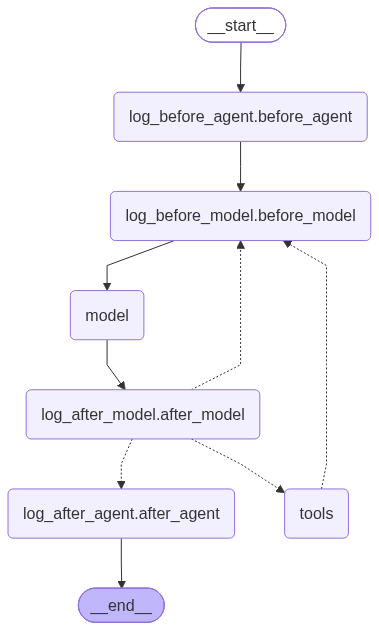

图节点： ['__start__', 'model', 'tools', 'log_before_agent.before_agent', 'log_before_model.before_model', 'log_after_model.after_model', 'log_after_agent.after_agent', '__end__']


In [9]:
# 在 Notebook 中直接渲染 Agent 的执行图
from IPython.display import Image, display

# agent 是上面「生命周期钩子」一节创建的：带 get_time 工具 + 4 个钩子
display(Image(agent.get_graph().draw_mermaid_png()))

# 图里的节点（钩子会作为独立节点串在 model 前后）
print("图节点：", list(agent.get_graph().nodes))


In [10]:
# 也可以拿到 Mermaid 文本，方便复制到支持 mermaid 的地方查看
print(agent.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	model(model)
	tools(tools)
	log_before_agent\2ebefore_agent(log_before_agent.before_agent)
	log_before_model\2ebefore_model(log_before_model.before_model)
	log_after_model\2eafter_model(log_after_model.after_model)
	log_after_agent\2eafter_agent(log_after_agent.after_agent)
	__end__([<p>__end__</p>]):::last
	__start__ --> log_before_agent\2ebefore_agent;
	log_after_model\2eafter_model -.-> log_after_agent\2eafter_agent;
	log_after_model\2eafter_model -.-> log_before_model\2ebefore_model;
	log_after_model\2eafter_model -.-> tools;
	log_before_agent\2ebefore_agent --> log_before_model\2ebefore_model;
	log_before_model\2ebefore_model --> model;
	model --> log_after_model\2eafter_model;
	tools -.-> log_before_model\2ebefore_model;
	log_after_agent\2eafter_agent --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



#### 要点回顾

1. 装饰器把普通函数变成 `AgentMiddleware`，直接放进 `create_agent(middleware=[...])`。
2. 生命周期钩子：`before_agent`/`after_agent` 整轮各一次；`before_model`/`after_model` 每次模型调用各一次。
3. `@dynamic_prompt` 动态生成系统提示；`@wrap_model_call` / `@wrap_tool_call` 通过 `handler(request)` 包裹调用，可重试、改写、短路。
4. `state_schema` 扩展状态、`can_jump_to` + `{"jump_to": ...}` 实现条件跳转。
5. 同步/异步都支持；需要更复杂的组合时可改用类式 `AgentMiddleware`。